# What each step diagnostic measures

This notebook explains the six diagnostics of `saddle_problem.jl`, so that the
tables in the other three can be read. Each one is described by what it measures
and by when it does not apply, and each claim is demonstrated on a run rather
than asserted.

The two Cauchy statistics are reconciled in Section 3 and the truncation
condition is checked iteration by iteration in Section 4.

In [1]:
const SADDLEDIR = @__DIR__
using Pkg; Pkg.activate(joinpath(SADDLEDIR, "..", ".."))
include(joinpath(SADDLEDIR, "..", "saddle_problem.jl"))

const SD_MU = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0, 8.0, 128.0]
mk_cap(μm) = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = min(MU0, μm), μ_max = μm)

const SD_MODELS = [("ExactHessian", () -> ExactHessian()),
                   ("SR1",          () -> SR1Model(mem = 10)),
                   ("LBFGS",        () -> LBFGSModel(mem = 5))]

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


3-element Vector{Tuple{String, Function}}:
 ("ExactHessian", var"#37#40"())
 ("SR1", var"#38#41"())
 ("LBFGS", var"#39#42"())

## 1. The table

`trunc`, `inside` and `krylov` come from `step_classes`. `cauchy` is the
cosine-based fraction of `hypotheses_report`. `cg1` is the fraction of iterations
with `cg_iters == 1`. `cos_min` is the minimum of $\cos(s_k,-g_k)$ over the run.

`cauchy` and `cg1` answer the same question two ways. Section 3 shows where they
separate and why.

In [2]:
"""
    sd_run(model, μm) -> NamedTuple

One run, with the iterate path from the solver's callback and every diagnostic
the table needs. Nothing is recomputed from the iterates that the trace already
carries.
"""
function sd_run(mkmodel, μm; subsolver = () -> SteihaugCG())
    st, xs = solve_path(rule = mk_cap(μm), model = mkmodel(), subsolver = subsolver(),
                        kmax = KMAX, tol = TOL)
    ss = st.solver_specific
    cg   = ss[:cg_iters_trajectory]
    cosc = ss[:cos_cauchy_trajectory]
    tr, ins, kry = step_classes(ss)
    return (st = st, xs = xs, ss = ss, status = st.status, iter = st.iter,
            trunc = tr, inside = ins, krylov = kry,
            cauchy = hypotheses_report(st).cauchy_fraction,
            cg1 = (isempty(cg) || all(==(0), cg)) ? NaN : count(==(1), cg) / length(cg),
            cos_min = (fin = filter(isfinite, cosc); isempty(fin) ? NaN : minimum(fin)))
end

SD = Dict{Tuple{String, Float64}, Any}()
println("="^104)
println("TABLE 1. R-grad capped, truncated CG. The six columns of the brief.")
println("="^104)
@printf("%-14s %8s %12s %7s %8s %8s %8s %9s %9s %10s\n",
        "model", "mu_max", "status", "iter", "trunc", "inside", "krylov",
        "cauchy", "cg1", "cos_min")
println("-"^104)
for (mnm, mkm) in SD_MODELS, μm in SD_MU
    r = sd_run(mkm, μm)
    SD[(mnm, μm)] = r
    @printf("%-14s %8.2f %12s %7d %8.3f %8.3f %8.3f %9.4f %9.4f %10.6f\n",
            mnm, μm, string(r.status), r.iter, r.trunc, r.inside, r.krylov,
            r.cauchy, r.cg1, r.cos_min)
end

TABLE 1. R-grad capped, truncated CG. The six columns of the brief.
model            mu_max       status    iter    trunc   inside   krylov    cauchy       cg1    cos_min
--------------------------------------------------------------------------------------------------------
ExactHessian       0.01     max_iter    2000    1.000    0.000    0.000    1.0000    1.0000   1.000000
ExactHessian       0.05     max_iter    2000    1.000    0.000    0.000    1.0000    1.0000   1.000000
ExactHessian       0.10     max_iter    2000    1.000    0.000    0.000    1.0000    1.0000   1.000000
ExactHessian       0.30     max_iter    2000    1.000    0.000    0.001    0.9995    0.9995   0.877285
ExactHessian       0.50     max_iter    2000    0.999    0.000    0.001    0.9990    0.9990   0.877285
ExactHessian       1.00     max_iter    2000    0.999    0.000    0.002    0.9985    0.9985   0.877285
ExactHessian       2.00     max_iter    2000    0.998    0.001    0.002    0.9985    0.9985   0.877285
Exa

## 2. The six diagnostics

### `step_classes`

Three classes, as fractions of the iterations that happened.

1. **Truncated at the boundary**, `cg_iters == 1` and the step active. The
   Hessian touched neither the direction nor the length. This is gradient descent
   in disguise, and it is the only one of the three that is.
2. **Stopped inside after one CG iteration**. The direction is $-g_k$ and the
   Hessian sets the length, through the exact line search on the model.
3. **Two or more CG iterations.**

Does not apply under `ExactMS`, which reports `cg_iters == 0` throughout. The
function returns `(NaN, NaN, NaN)` there rather than a fraction of zero, so the
caller reads the angle instead.

### `eig_deviation`

$\sin$ of the angle between $H_kg_k$ and $g_k$. Zero exactly when $g_k$ is an
eigenvector of $H_k$. On this function the Hessian is diagonal on the axis
$p_2 = 0$ and the gradient lies along $e_1$ there, so the deviation vanishes on
the axis and the iterates approach it.

### `z1_ratio`

$\|z_1\|/\Delta_k$, where $z_1$ is the first Steihaug iterate, the exact
minimiser of the model along $-g$. Steihaug truncates at the first iteration when
this reaches one.

Written out, the truncation condition is
$$\Delta_k \;\leq\; \frac{\|g_k\|^3}{g_k^{\!\top}H_kg_k},$$
which for a gradient-scaled radius $\Delta_k = \mu_k\|g_k\|$ reads
$$\mu_k \;\leq\; \frac{\|g_k\|^2}{g_k^{\!\top}H_kg_k},$$
a reciprocal curvature. A cap below that quantity truncates every step.

Returns `Inf` when $g^{\!\top}Hg \leq 0$, where conjugate gradient goes straight
to the boundary.

### `spectrum_variance`

The $g$-weighted variance of the spectrum of $H(x)$, the constant in the
`ExactMS` angle law of the first notebook.

### `loglog_fit`

Slope, intercept, $R^2$ and the number of usable points, returning `NaN` below
five of them. Report $n$ and $R^2$ beside every slope taken from it.

### `nearest_crit`

The nearest critical point and its distance. `which_crit` is written in terms of
it, so a limit point is classified by one distance computation.

In [3]:
println("="^96)
println("step_classes does not apply under ExactMS")
println("="^96)
for (snm, mks) in (("SteihaugCG", () -> SteihaugCG()), ("ExactMS", () -> ExactMS()))
    r = sd_run(() -> ExactHessian(), 0.5; subsolver = mks)
    cg = r.ss[:cg_iters_trajectory]
    @printf("%-12s cg_iters unique = %-18s step_classes = (%.3f, %.3f, %.3f)\n",
            snm, string(unique(cg)), r.trunc, r.inside, r.krylov)
end

println("\n", "="^96)
println("eig_deviation vanishes on the axis p2 = 0, where g is an eigenvector of H")
println("="^96)
@printf("%-26s %14s %14s %14s\n", "x", "eig_deviation", "z1_ratio(x,1)", "spec variance")
println("-"^96)
for p in ([0.30, 0.0], [0.60, 0.0], [-0.50, 0.0], X0_DEFAULT, [0.2, 0.5], [-0.3, -0.4])
    @printf("(%+.4f, %+.4f)%10s %14.3e %14.4g %14.6f\n",
            p[1], p[2], "", eig_deviation(p), z1_ratio(p, 1.0), spectrum_variance(p))
end

println("\n", "="^96)
println("z1_ratio returns Inf where g'Hg <= 0")
println("="^96)
@printf("%-26s %14s %14s\n", "x", "g'Hg", "z1_ratio(x,1)")
println("-"^96)
NEGCURV = 0
for a in range(-0.9, 1.2; length = 40), b in range(-0.8, 0.8; length = 21)
    p = [a, b]; g = grad(p)
    norm(g) < 1e-8 && continue
    q = dot(g, hess(p) * g)
    if q <= 0 && NEGCURV < 6
        @printf("(%+.4f, %+.4f)%10s %14.4e %14s\n", a, b, "", q, string(z1_ratio(p, 1.0)))
        global NEGCURV += 1
    end
end
NEGCURV == 0 && println("  no grid point with g'Hg <= 0 was found on this scan")

println("\n", "="^96)
println("loglog_fit returns NaN below five usable points")
println("="^96)
for m in (3, 4, 5, 8)
    x = collect(1.0:m); y = 3.0 .* x .^ 1.5
    fit = loglog_fit(x, y)
    @printf("  %d points: slope = %8s   R2 = %8s   n = %d\n",
            m, string(round(fit.slope, digits = 4)),
            string(round(fit.r2, digits = 6)), fit.n)
end

println("\n", "="^96)
println("nearest_crit and which_crit agree, one distance computation")
println("="^96)
@printf("%-26s %-10s %12s %-10s\n", "x", "nearest", "dist", "which_crit")
println("-"^96)
for p in (ORIGIN, SADDLE, MINP, MINM, X0_DEFAULT, [5.0, 5.0])
    nc = nearest_crit(p)
    @printf("(%+.4f, %+.4f)%10s %-10s %12.3e %-10s\n",
            p[1], p[2], "", nc.name, nc.dist, which_crit(p))
end

step_classes does not apply under ExactMS
SteihaugCG   cg_iters unique = [2, 1]             step_classes = (0.999, 0.000, 0.001)
ExactMS      cg_iters unique = [0]                step_classes = (NaN, NaN, NaN)

eig_deviation vanishes on the axis p2 = 0, where g is an eigenvector of H
x                           eig_deviation  z1_ratio(x,1)  spec variance
------------------------------------------------------------------------------------------------
(+0.3000, +0.0000)                0.000e+00            Inf       0.000000
(+0.6000, +0.0000)                0.000e+00            0.3       0.000000
(-0.5000, +0.0000)                0.000e+00         0.2083       0.000000
(-0.5000, +0.6000)                2.415e-01         0.2965       1.910412
(+0.2000, +0.5000)                6.436e-01         0.3996       0.535608
(-0.3000, -0.4000)                2.649e-01         0.2287       0.515476

z1_ratio returns Inf where g'Hg <= 0
x                                    g'Hg  z1_ratio(x,1)
-------

## 3. The two Cauchy statistics, reconciled

`cauchy` tests $\cos(s_k,-g_k) \approx 1$ within $10^{-12}$ and `cg1` tests the
Krylov dimension. They answer the same question two ways and can disagree.

The natural explanation is that they separate when $g_k$ is close to an
eigenvector of $H_k$. The second CG direction would then add nothing to the
direction while still being counted, so the cosine test would count more. On
this function the iterates approach the axis $p_2 = 0$, where the Hessian is
diagonal and the gradient is an eigenvector, so the explanation is available.

It is tested below and it does not survive. `eig_deviation` at the disagreeing
iterations is compared with `eig_deviation` at the agreeing ones, and `z1_ratio`
at both, so a second mechanism is available to the same table.

**We use `cg1` as the definition of truncation and the cosine as corroboration.**
The truncation condition is a statement about conjugate gradient, so the Krylov
dimension is what states it, and the angle is a consequence.

In [4]:
"""
    disagreement(r) -> NamedTuple

Per-iteration comparison of the two Cauchy statistics on one run, with
`eig_deviation` at the iterate that produced each step.

Iteration `i` leaves `xs[i]`, so the deviation is taken there and not at the
point reached.
"""
function disagreement(r)
    cg   = r.ss[:cg_iters_trajectory]
    cosc = r.ss[:cos_cauchy_trajectory]
    Δ = r.ss[:delta_trajectory]
    n = min(length(cg), length(cosc), length(r.xs) - 1, length(Δ) - 1)
    n <= 0 && return (n = 0, dev = Float64[], z1 = Float64[], gap = Float64[],
                      cosone = Bool[], cgone = Bool[], dis = Bool[])
    dev    = [eig_deviation(r.xs[i]) for i in 1:n]
    z1     = [z1_ratio(r.xs[i], Δ[i]) for i in 1:n]
    gap    = [abs(1 - cosc[i]) for i in 1:n]
    cosone = [isfinite(cosc[i]) && abs(cosc[i] - 1) <= 1e-12 for i in 1:n]
    cgone  = [cg[i] == 1 for i in 1:n]
    return (n = n, dev = dev, z1 = z1, gap = gap, cosone = cosone,
            cgone = cgone, dis = cosone .!= cgone)
end

println("="^112)
println("TABLE 2. Where the two Cauchy statistics disagree, and the angle there.")
println("="^112)
@printf("%-14s %7s %7s %8s %8s %7s | %12s %12s | %13s %13s\n",
        "model", "mu_max", "iters", "cauchy", "cg1", "disagr",
        "dev dis med", "dev agr med", "1-z1 dis med", "1-z1 agr med")
println("-"^116)
DIS = Dict{Tuple{String, Float64}, Any}()
med(v) = isempty(v) ? NaN : (s = sort(v); m = length(s);
                             isodd(m) ? s[(m+1)÷2] : (s[m÷2] + s[m÷2+1]) / 2)
for (mnm, _) in SD_MODELS, μm in SD_MU
    r = SD[(mnm, μm)]
    d = disagreement(r)
    DIS[(mnm, μm)] = d
    d.n == 0 && continue
    dd = [d.dev[i] for i in 1:d.n if d.dis[i] && isfinite(d.dev[i])]
    da = [d.dev[i] for i in 1:d.n if !d.dis[i] && isfinite(d.dev[i])]
    zd = [1 - d.z1[i] for i in 1:d.n if d.dis[i] && isfinite(d.z1[i])]
    za = [1 - d.z1[i] for i in 1:d.n if !d.dis[i] && isfinite(d.z1[i])]
    @printf("%-14s %7.2f %7d %8.4f %8.4f %7d | %12.4e %12.4e | %13.4e %13.4e\n",
            mnm, μm, d.n, r.cauchy, r.cg1, count(d.dis),
            med(dd), med(da), med(zd), med(za))
end

println()
println("`1-z1 dis med` is 1 - ||z1||/Delta at the disagreeing iterations. A value")
println("near zero is the first CG step landing just inside the boundary.")

# The two explanations, weighed against each other on the runs that disagree.
let dd = Float64[], da = Float64[], zd = Float64[], za = Float64[],
    gd = Float64[], ga = Float64[]
    for (mnm, _) in SD_MODELS, μm in SD_MU
        d = DIS[(mnm, μm)]
        (d.n == 0 || count(d.dis) == 0) && continue
        for i in 1:d.n
            if d.dis[i]
                isfinite(d.dev[i]) && push!(dd, d.dev[i])
                isfinite(d.z1[i])  && push!(zd, 1 - d.z1[i])
                isfinite(d.gap[i]) && push!(gd, d.gap[i])
            else
                isfinite(d.dev[i]) && push!(da, d.dev[i])
                isfinite(d.z1[i])  && push!(za, 1 - d.z1[i])
                isfinite(d.gap[i]) && push!(ga, d.gap[i])
            end
        end
    end
    println("\n", "="^88)
    println("The two explanations, pooled over the runs that disagree at all")
    println("="^88)
    @printf("%-34s %14s %14s %14s\n", "quantity", "min", "median", "max")
    println("-"^88)
    for (nm, v) in (("eig_deviation, disagreeing", dd),
                    ("eig_deviation, agreeing", da),
                    ("1 - z1_ratio, disagreeing", zd),
                    ("1 - z1_ratio, agreeing", za),
                    ("|1 - cos(s,-g)|, disagreeing", gd),
                    ("|1 - cos(s,-g)|, agreeing", ga))
        @printf("%-34s %14.4e %14.4e %14.4e\n", nm,
                isempty(v) ? NaN : minimum(v), med(v),
                isempty(v) ? NaN : maximum(v))
    end
    println()
    if !isempty(dd) && !isempty(da)
        if med(dd) < 0.1 * med(da)
            println("The disagreeing iterations ARE the near-eigenvector ones.")
        else
            println("The disagreeing iterations are NOT the near-eigenvector ones.")
            @printf("Their median eig_deviation is %.4e against %.4e at the agreeing\n",
                    med(dd), med(da))
            println("ones, so the angle between H g and g does not separate them.")
        end
    end
    if !isempty(zd) && !isempty(gd)
        @printf("\nPredicted |1 - cos| from the boundary gap, eps^2/2 with eps = %.3e:\n",
                med(zd))
        @printf("  eps^2/2                       = %.3e\n", med(zd)^2 / 2)
        @printf("  measured median |1 - cos|     = %.3e\n", med(gd))
        @printf("  the cosine test threshold     = %.3e\n", 1e-12)
    end
    if !isempty(zd) && med(zd) < 1e-6
        @printf("\n1 - ||z1||/Delta has median %.3e at the disagreeing iterations, so the\n",
                med(zd))
        println("first CG step lands just inside the boundary there. Conjugate gradient")
        println("takes a second iteration that moves the step by a negligible amount, the")
        println("Krylov dimension counts two, and the direction stays within 1e-12 of -g.")
        println("Boundary crossing separates the two statistics; the eigenvector angle")
        println("does not.")
    end
end

println("\nIn every disagreeing iteration, which way does it go?")
@printf("%-14s %8s %14s %14s\n", "model", "mu_max", "cos yes, cg no", "cg yes, cos no")
println("-"^60)
for (mnm, _) in SD_MODELS, μm in SD_MU
    d = DIS[(mnm, μm)]
    d.n == 0 && continue
    a = count(i -> d.cosone[i] && !d.cgone[i], 1:d.n)
    b = count(i -> !d.cosone[i] && d.cgone[i], 1:d.n)
    (a + b) == 0 && continue
    @printf("%-14s %8.2f %14d %14d\n", mnm, μm, a, b)
end

TABLE 2. Where the two Cauchy statistics disagree, and the angle there.
model           mu_max   iters   cauchy      cg1  disagr |  dev dis med  dev agr med |  1-z1 dis med  1-z1 agr med
--------------------------------------------------------------------------------------------------------------------
ExactHessian      0.01    2000   1.0000   1.0000       0 |          NaN   2.2233e-01 |           NaN   -4.5414e+02
ExactHessian      0.05    2000   1.0000   1.0000       0 |          NaN   8.8147e-08 |           NaN   -5.3342e+02
ExactHessian      0.10    2000   1.0000   1.0000       0 |          NaN   0.0000e+00 |           NaN   -5.2000e+02
ExactHessian      0.30    2000   0.9995   0.9995       0 |          NaN   0.0000e+00 |           NaN   -5.0688e+02
ExactHessian      0.50    2000   0.9990   0.9990       0 |          NaN   0.0000e+00 |           NaN   -5.0443e+02
ExactHessian      1.00    2000   0.9985   0.9985       0 |          NaN   0.0000e+00 |           NaN   -5.0288e+02
ExactH

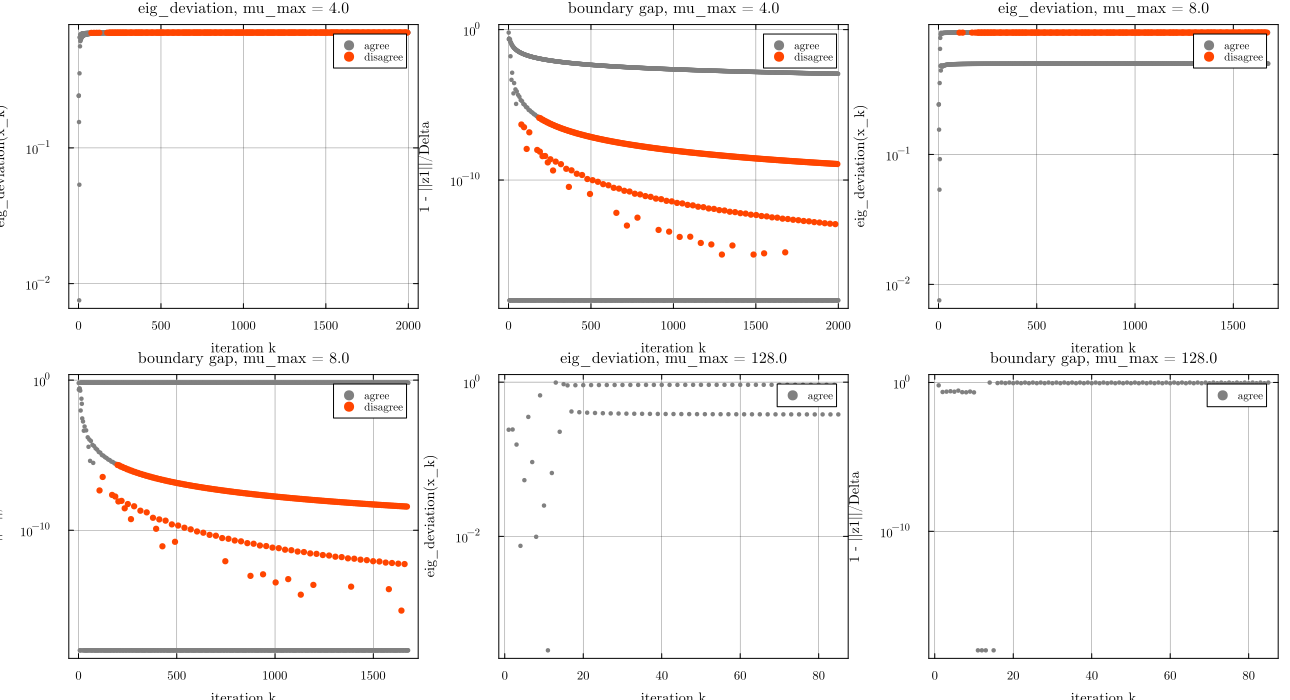

In [5]:
# The figure: the per-iteration disagreement against the angle it is predicted by.
let picks = [("ExactHessian", 4.0), ("ExactHessian", 8.0), ("ExactHessian", 128.0)]
    plts = []
    for (mnm, μm) in picks
        d = DIS[(mnm, μm)]
        d.n == 0 && continue
        ia = [i for i in 1:d.n if !d.dis[i] && isfinite(d.dev[i])]
        id = [i for i in 1:d.n if  d.dis[i] && isfinite(d.dev[i])]
        p = scatter(ia, d.dev[ia]; label = "agree", ms = 2.5, mc = :gray,
                    markerstrokewidth = 0, yscale = :log10,
                    xlabel = "iteration k", ylabel = "eig_deviation(x_k)",
                    title = "eig_deviation, mu_max = $μm", legend = :topright)
        isempty(id) || scatter!(p, id, d.dev[id]; label = "disagree", ms = 3.5,
                                mc = :orangered, markerstrokewidth = 0)
        push!(plts, p)

        # The same iterations against the quantity that does separate them.
        za = [max(1 - d.z1[i], 1e-18) for i in ia]
        zd = [max(1 - d.z1[i], 1e-18) for i in id]
        q = scatter(ia, za; label = "agree", ms = 2.5, mc = :gray,
                    markerstrokewidth = 0, yscale = :log10,
                    xlabel = "iteration k", ylabel = "1 - ||z1||/Delta",
                    title = "boundary gap, mu_max = $μm", legend = :topright)
        isempty(id) || scatter!(q, id, zd; label = "disagree", ms = 3.5,
                                mc = :orangered, markerstrokewidth = 0)
        push!(plts, q)
    end
    if !isempty(plts)
        fig = plot(plts...; layout = (2, length(plts) ÷ 2),
                   size = (430 * (length(plts) ÷ 2), 700))
        savefig(fig, joinpath(SADDLEDIR, "step_diagnostics_fig1_cauchy_reconcile.pdf"))
        display(fig)
    end
end

## 4. The truncation condition, checked iteration by iteration

`z1_ratio(x_k, Δ_k) >= 1` predicts that Steihaug truncates at its first
iteration, so `cg_iters == 1`. The prediction is compared with the observed
`cg_iters` at every iteration of several runs.

The disagreements are listed individually rather than as a rate, with the
quantities that might explain them beside each one.

`z1_ratio` models one of the three ways Steihaug can stop. Conjugate gradient
also stops on negative curvature and on the forcing condition
$\|r\| \leq \min(\chi, \|g\|^\theta)\|g\|$, and neither is in the ratio. So the
prediction is expected to be one-sided, never claiming truncation that did not
happen, and the table below is where that expectation is checked.

One limit of the diagnostic first. `z1_ratio` reads the **true** Hessian,
through `hess`, and conjugate gradient runs on the **model** Hessian. The two
coincide under `ExactHessian` and nowhere else, so a disagreement under `SR1`
or `LBFGS` says that the model differs from the truth and says nothing about
the truncation condition. The counts are given for all three models and the
individual rows only for `ExactHessian`, where the prediction is about the
matrix conjugate gradient actually saw.

In [6]:
"""
    truncation_check(r) -> (n, pred, obs, bad)

`z1_ratio(x_k, Δ_k) >= 1` against `cg_iters[k] == 1`, iteration by iteration.

Iteration `k` leaves `xs[k]` with radius `Δ[k]`, so both are taken at index `k`.
The radius trajectory is one longer than the per-iteration ones, which is what
that alignment is.
"""
function truncation_check(r)
    cg = r.ss[:cg_iters_trajectory]
    Δ  = r.ss[:delta_trajectory]
    n  = min(length(cg), length(Δ) - 1, length(r.xs) - 1)
    n <= 0 && return (n = 0, ratio = Float64[], pred = Bool[], obs = Bool[], bad = Int[])
    ratio = [z1_ratio(r.xs[i], Δ[i]) for i in 1:n]
    pred  = [ratio[i] >= 1 for i in 1:n]
    obs   = [cg[i] == 1 for i in 1:n]
    return (n = n, ratio = ratio, pred = pred, obs = obs,
            bad = [i for i in 1:n if pred[i] != obs[i]])
end

println("="^100)
println("TABLE 3. The truncation prediction against the observed Krylov dimension.")
println("="^100)
@printf("%-14s %8s %8s %12s %12s %12s\n",
        "model", "mu_max", "iters", "predicted", "observed", "disagreements")
println("-"^100)
TRC = Dict{Tuple{String, Float64}, Any}()
for (mnm, _) in SD_MODELS, μm in SD_MU
    t = truncation_check(SD[(mnm, μm)])
    TRC[(mnm, μm)] = t
    t.n == 0 && continue
    @printf("%-14s %8.2f %8d %12d %12d %12d\n",
            mnm, μm, t.n, count(t.pred), count(t.obs), length(t.bad))
end

TABLE 3. The truncation prediction against the observed Krylov dimension.
model            mu_max    iters    predicted     observed disagreements
----------------------------------------------------------------------------------------------------
ExactHessian       0.01     2000         2000         2000            0
ExactHessian       0.05     2000         2000         2000            0
ExactHessian       0.10     2000         2000         2000            0
ExactHessian       0.30     2000         1999         1999            0
ExactHessian       0.50     2000         1998         1998            0
ExactHessian       1.00     2000         1997         1997            0
ExactHessian       2.00     2000         1996         1997            1
ExactHessian       4.00     2000          667          669            2
ExactHessian       8.00     1678          555          557            2
ExactHessian     128.00       85            4            7            3
SR1                0.01     2000

In [7]:
println("\n", "="^116)
println("Every ExactHessian disagreement, one line each, with what stands beside it.")
println("z1_ratio reads the true Hessian, so only these rows test the condition.")
println("="^116)
@printf("%-14s %8s %7s %12s %8s %8s %14s %12s %12s\n",
        "model", "mu_max", "k", "z1_ratio", "pred", "cg_iters", "eig_dev",
        "Delta_k", "|g_k|")
println("-"^116)
NBAD = 0
for (mnm, _) in SD_MODELS, μm in SD_MU
    mnm == "ExactHessian" || continue
    t = TRC[(mnm, μm)]
    r = SD[(mnm, μm)]
    t.n == 0 && continue
    cg = r.ss[:cg_iters_trajectory]; Δ = r.ss[:delta_trajectory]
    g  = r.ss[:grad_trajectory]
    for i in t.bad
        global NBAD += 1
        NBAD > 40 && continue
        @printf("%-14s %8.2f %7d %12.5f %8s %8d %14.4e %12.4e %12.4e\n",
                mnm, μm, i - 1, t.ratio[i], string(t.pred[i]), cg[i],
                eig_deviation(r.xs[i]), Δ[i], g[i])
    end
end
@printf("\n%d disagreements under ExactHessian", NBAD)
NBAD > 40 && @printf(", the first 40 listed")
println(".")

println("\nDisagreements by model, over all ten caps:")
@printf("%-14s %10s %14s %10s\n", "model", "iterations", "disagreements", "rate")
println("-"^54)
for (mnm, _) in SD_MODELS
    ni = sum(TRC[(mnm, μm)].n for μm in SD_MU)
    nb = sum(length(TRC[(mnm, μm)].bad) for μm in SD_MU)
    @printf("%-14s %10d %14d %10.4f\n", mnm, ni, nb, ni == 0 ? NaN : nb / ni)
end

if NBAD > 0
    println("\nWhat they have in common:")
    rs = Float64[]; dv = Float64[]
    for (mnm, _) in SD_MODELS, μm in SD_MU
        mnm == "ExactHessian" || continue
        t = TRC[(mnm, μm)]; r = SD[(mnm, μm)]
        t.n == 0 && continue
        for i in t.bad
            push!(rs, t.ratio[i]); push!(dv, eig_deviation(r.xs[i]))
        end
    end
    fr = filter(isfinite, rs)
    @printf("  z1_ratio at the disagreements : min %.6f  median %.6f  max %.6f\n",
            isempty(fr) ? NaN : minimum(fr), med(fr), isempty(fr) ? NaN : maximum(fr))
    @printf("  how many lie within 1e-6 of 1 : %d of %d\n",
            count(x -> abs(x - 1) <= 1e-6, fr), length(fr))
    @printf("  how many are exactly Inf      : %d\n", count(isinf, rs))
    fd = filter(isfinite, dv)
    @printf("  eig_deviation there           : min %.3e  median %.3e  max %.3e\n",
            isempty(fd) ? NaN : minimum(fd), med(fd), isempty(fd) ? NaN : maximum(fd))
end


Every ExactHessian disagreement, one line each, with what stands beside it.
z1_ratio reads the true Hessian, so only these rows test the condition.
model            mu_max       k     z1_ratio     pred cg_iters        eig_dev      Delta_k        |g_k|
--------------------------------------------------------------------------------------------------------------------
ExactHessian       2.00       3      0.74290    false        1     7.5345e-03   6.1095e-02   3.0547e-02
ExactHessian       4.00       3      0.74290    false        1     7.5345e-03   6.1095e-02   3.0547e-02
ExactHessian       4.00       4      0.76071    false        1     5.3537e-02   3.1586e-02   7.8966e-03
ExactHessian       8.00       3      0.74290    false        1     7.5345e-03   6.1095e-02   3.0547e-02
ExactHessian       8.00       4      0.76071    false        1     5.3537e-02   3.1586e-02   7.8966e-03
ExactHessian     128.00       3      0.74290    false        1     7.5345e-03   6.1095e-02   3.0547e-02
ExactH

In [8]:
println("\nDONE. Figures written to ", SADDLEDIR)


DONE. Figures written to c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\FINAL\Cauchy_stats
